# Customer Churn Analysis Project

## Objective
The objective of this project is to analyze customer behavior patterns and identify factors contributing to customer churn using transactional, engagement, and support datasets.

## Datasets Used
- Customers Dataset
- Orders Dataset
- Support Tickets Dataset
- Web Activity Dataset
- Churn Labels Dataset
- RFM Snapshot Dataset

## Data Audit, EDA & Business Understanding

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [7]:
customers = pd.read_csv("../datasets/customers.csv")
orders = pd.read_csv("../datasets/orders.csv")
support = pd.read_csv("../datasets/support_tickets.csv")
web = pd.read_csv("../datasets/web_events_snapshot.csv")
interventions = pd.read_csv("../datasets/intervention_history.csv")
churn = pd.read_csv("../datasets/churn_labels.csv")
snapshot = pd.read_csv("../datasets/rfm_modeling_snapshot.csv")

In [8]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support:", support.shape)
print("Web:", web.shape)
print("Interventions:", interventions.shape)
print("Churn:", churn.shape)
print("Snapshot:", snapshot.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support: (1921, 8)
Web: (2400, 10)
Interventions: (2400, 5)
Churn: (2400, 4)
Snapshot: (2400, 29)


In [9]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [10]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [11]:
support.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [12]:
web.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [13]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB


In [14]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  str    
 1   customer_id    10009 non-null  str    
 2   order_date     10009 non-null  str    
 3   category       10009 non-null  str    
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 782.1 KB


In [15]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

In [16]:
churn['churn_next_60d'].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

In [18]:
merged = snapshot.merge(churn, on='customer_id')

In [19]:
merged.columns

Index(['customer_id', 'snapshot_date_x', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d',
       'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d',
       'category_diversity_180d', 'ticket_count_90d',
       'negative_ticket_rate_90d', 'avg_resolution_hours_90d',
       'days_since_signup', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago',
       'churn_next_60d_x', 'split_x', 'snapshot_date_y', 'churn_next_60d_y',
       'split_y'],
      dtype='str')

### Missing Values Analysis

In [21]:
customers.isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

In [22]:
orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [23]:
support.isnull().sum()

ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

In [24]:
snapshot.isnull().sum()

customer_id                    0
snapshot_date                  0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
churn_next_60d                 0
split                          0
dtype: int64

In [25]:
def missing_percent(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    
    result = pd.DataFrame({
        'Missing Values': missing,
        'Percentage': percent
    })
    
    return result[result['Missing Values'] > 0].sort_values(
        by='Percentage',
        ascending=False
    )

In [26]:
missing_percent(customers)

,Missing Values,Percentage
loyalty_tier,1386,57.750000
skin_type,401,16.708333


In [27]:
missing_percent(orders)

,Missing Values,Percentage
rating,80,0.799281


### Observation
- `loyalty_tier` contains a high percentage of missing values (~58%).
- `skin_type` contains moderate missingness (~17%).
- Missing values may require imputation or careful handling before modeling.

### Duplicate Analysis

In [28]:
orders.duplicated().sum()

np.int64(0)

In [29]:
customers.duplicated().sum()

np.int64(0)

### Summary Statistics

In [30]:
orders.describe()

,order_date,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
mean,2025-04-14 01:17:41.404735,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
min,2024-01-09 00:00:00,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,2024-12-19 00:00:00,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,2025-05-08 00:00:00,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,2025-09-06 00:00:00,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000
max,2025-11-29 00:00:00,4.000000,24789.380000,0.700000,11.000000,1.000000,5.000000
std,NaN,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465


# Order Amount Distribution

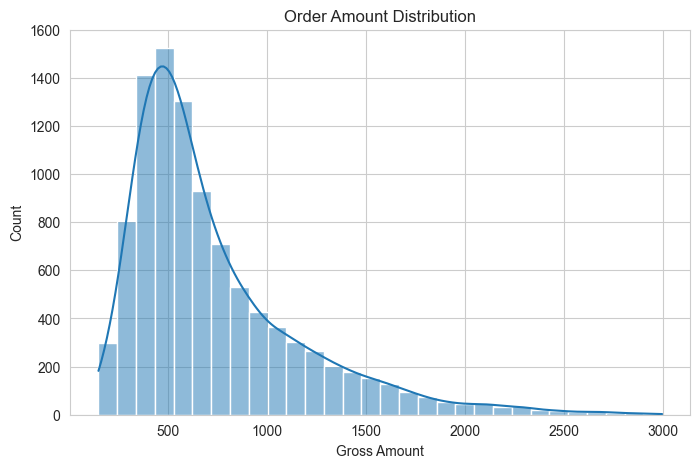

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders[orders['gross_amount'] < 3000]['gross_amount'],
    bins=30,
    kde=True
)

plt.title("Order Amount Distribution")
plt.xlabel("Gross Amount")
plt.show()

### Observation
The order amount distribution is right-skewed, with most purchases concentrated in lower-to-mid spending ranges and a smaller number of high-value orders.

# Return Rate Analysis

In [32]:
orders['returned'].value_counts()

returned
0    9334
1     675
Name: count, dtype: int64

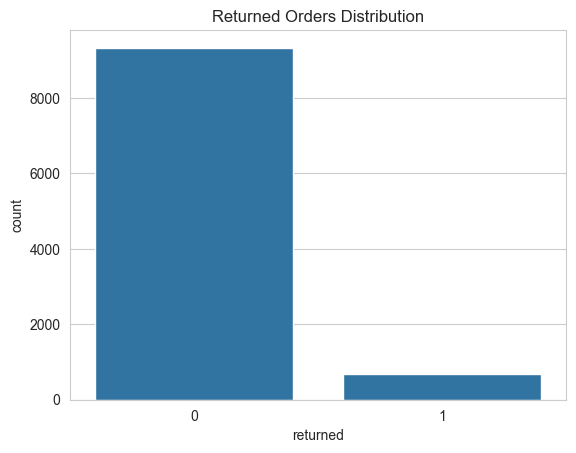

In [33]:
sns.countplot(x='returned', data=orders)

plt.title("Returned Orders Distribution")
plt.show()

### Observation
Most orders are not returned, indicating generally positive purchase satisfaction and operational performance.

# Purchase Frequency vs Churn

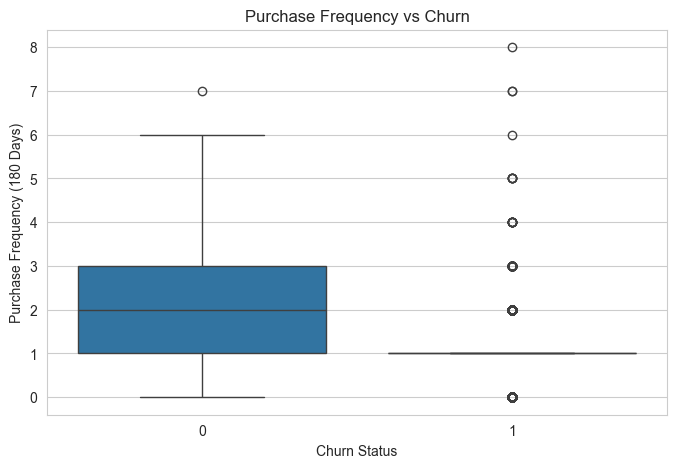

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_next_60d',
    y='frequency_180d',
    data=snapshot
)

plt.title("Purchase Frequency vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Purchase Frequency (180 Days)")

plt.show()

### Observation

Customers with lower purchase frequency tend to churn more frequently.
Non-churned customers generally show higher purchasing activity, indicating that repeat purchases are strongly associated with customer retention.

# Session activity vs Churn

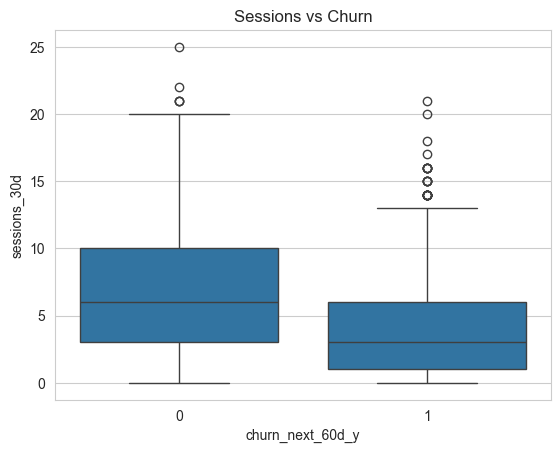

In [44]:
sns.boxplot(
    x='churn_next_60d_y',
    y='sessions_30d',
    data=merged
)

plt.title("Sessions vs Churn")
plt.show()

Customers with higher sessions_30d tend to churn LESS.

Customers who churned (1) generally have lower engagement.

### Observation
Customers with lower session activity tend to churn more frequently. Higher engagement appears associated with better customer retention.

### Correlation Analysis

In [35]:
numeric_cols = snapshot.select_dtypes(include=np.number)

corr_matrix = numeric_cols.corr()

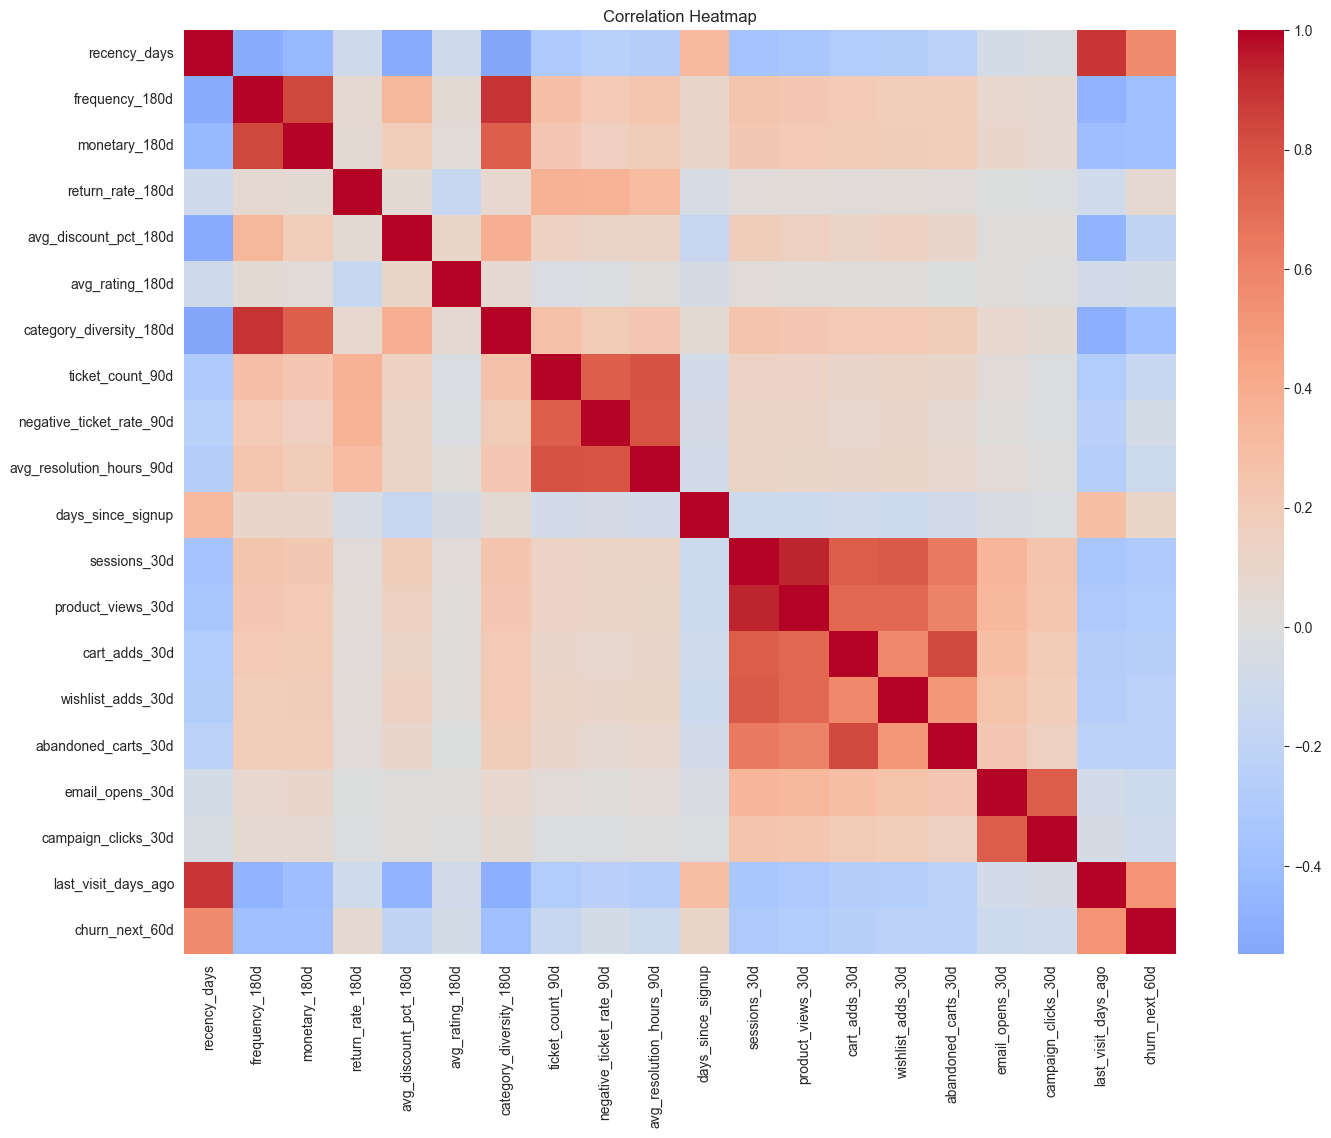

In [36]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [37]:
corr_with_churn = corr_matrix['churn_next_60d'].sort_values(ascending=False)

corr_with_churn

churn_next_60d              1.000000
recency_days                0.561125
last_visit_days_ago         0.526712
days_since_signup           0.107733
return_rate_180d            0.068692
negative_ticket_rate_90d   -0.072851
avg_rating_180d            -0.073095
campaign_clicks_30d        -0.096601
email_opens_30d            -0.116903
avg_resolution_hours_90d   -0.119360
ticket_count_90d           -0.152700
avg_discount_pct_180d      -0.190569
abandoned_carts_30d        -0.216053
wishlist_adds_30d          -0.232018
cart_adds_30d              -0.248782
product_views_30d          -0.287175
sessions_30d               -0.307330
category_diversity_180d    -0.382854
monetary_180d              -0.384785
frequency_180d             -0.393999
Name: churn_next_60d, dtype: float64

### Key Correlation Insights

- `recency_days` and `last_visit_days_ago` show strong positive correlation with churn, indicating inactive customers are more likely to leave.
- Engagement metrics such as `sessions_30d`, `product_views_30d`, and `frequency_180d` show negative correlation with churn.
- Customers with higher purchasing frequency and interaction activity tend to have better retention.

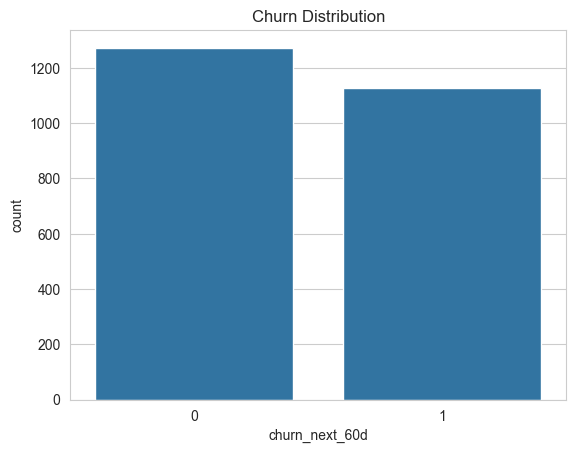

In [43]:
sns.countplot(x='churn_next_60d', data=churn)
plt.title("Churn Distribution")
plt.show()

### Observation
The churn distribution appears relatively balanced, reducing the likelihood of severe class imbalance issues during model training.

# Date Consistency Analysis

In [47]:
print("Orders Date Range:")
print(orders['order_date'].min(), "to", orders['order_date'].max())

print("\nCustomer Signup Date Range:")
print(customers['signup_date'].min(), "to", customers['signup_date'].max())

Orders Date Range:
2024-01-09 00:00:00 to 2025-11-29 00:00:00

Customer Signup Date Range:
2024-01-01 00:00:00 to 2025-09-15 00:00:00


### Observation
Customer signup dates and order activity dates fall within expected historical ranges, with no major future-dated inconsistencies identified.

# Join Integrity Checks

In [46]:
print("Customers:", customers['customer_id'].nunique())
print("Orders:", orders['customer_id'].nunique())
print("Snapshot:", snapshot['customer_id'].nunique())

Customers: 2400
Orders: 2400
Snapshot: 2400


In [41]:
orders['customer_id'].isin(customers['customer_id']).mean()

np.float64(1.0)

### Observation

All order records successfully mapped to existing customer IDs (100% join match rate), indicating no major key integrity issues across datasets.

# Potential Data Leakage Analysis

In [45]:
snapshot.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

Certain columns may contain future behavioral information or target-related patterns that could introduce leakage if used directly during predictive modeling. Care should be taken to exclude post-churn or future-derived variables during model training.

# Key Insights

1. Customers with lower engagement show higher churn probability.
2. Frequent product interactions are associated with improved retention.
3. Higher recency values correlate positively with churn.
4. Return behavior and support interactions may influence churn likelihood.
5. Missing values are primarily concentrated in loyalty-related features.

# Conclusion

This exploratory data analysis identified several important patterns associated with customer churn. Customer inactivity, reduced engagement, and lower purchase frequency appear strongly connected to churn behavior. The insights obtained from this analysis will support the next stages of feature engineering and predictive model development.